In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [27]:
# ── Load data ──────────────────────────────────────────────────────────────
ab  = pd.read_csv('AB1.csv',  header=None, names=['wavenumber', 'absorbance'])
cab = pd.read_csv('CAB1.csv', header=None, names=['wavenumber', 'absorbance'])

# FTIR convention: wavenumber axis runs high → low (4000 → 400 cm⁻¹)
ab  = ab.sort_values('wavenumber', ascending=False).reset_index(drop=True)
cab = cab.sort_values('wavenumber', ascending=False).reset_index(drop=True)

print(f"AB  : {len(ab)}  points  |  {ab.wavenumber.max():.1f} – {ab.wavenumber.min():.1f} cm⁻¹")
print(f"CAB : {len(cab)} points  |  {cab.wavenumber.max():.1f} – {cab.wavenumber.min():.1f} cm⁻¹")

AB  : 1754  points  |  3996.4 – 398.2 cm⁻¹
CAB : 1754 points  |  3996.4 – 398.2 cm⁻¹


In [29]:
# ── Optional smoothing ─────────────────────────────────────────────────────
WINDOW = 5   # set to 1 to disable smoothing

ab['smooth']  = ab['absorbance'].rolling(WINDOW,  center=True, min_periods=1).mean()
cab['smooth'] = cab['absorbance'].rolling(WINDOW, center=True, min_periods=1).mean()

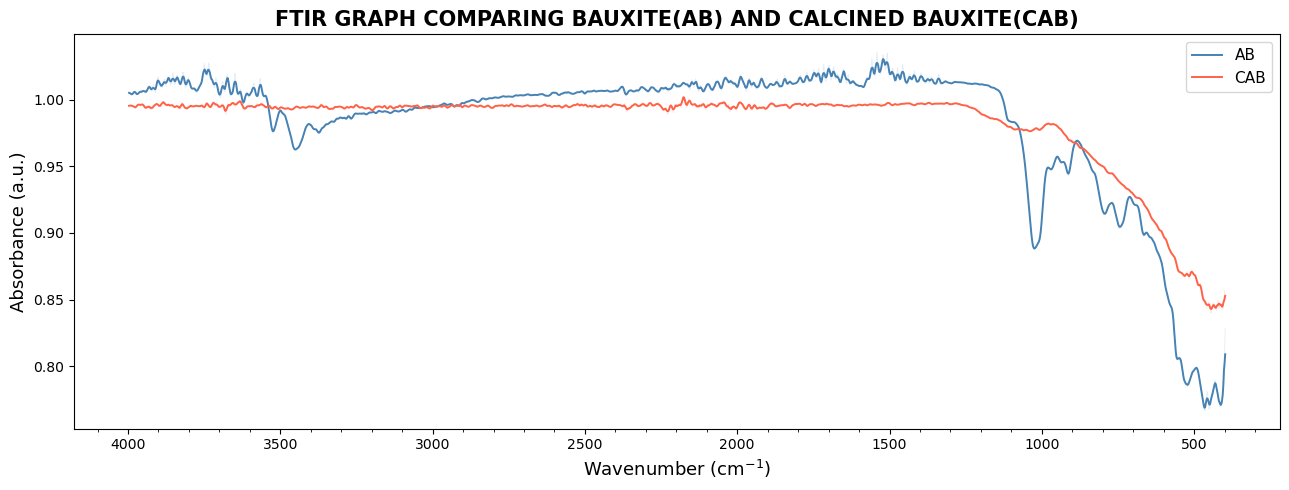

Figure saved as ftir_comparison.png


In [46]:
# ── Overlay plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

# Raw (faint) + smoothed line
ax.plot(ab['wavenumber'],  ab['absorbance'],  color='steelblue', alpha=0.15, linewidth=0.6)
ax.plot(ab['wavenumber'],  ab['smooth'],      color='steelblue', linewidth=1.4, label='AB')

ax.plot(cab['wavenumber'], cab['absorbance'], color='tomato',    alpha=0.15, linewidth=0.6)
ax.plot(cab['wavenumber'], cab['smooth'],     color='tomato',    linewidth=1.4, label='CAB')

# FTIR convention: x-axis reversed (4000 → 400)
ax.invert_xaxis()

ax.set_xlabel(r'Wavenumber (cm$^{-1}$)', fontsize=13)
ax.set_ylabel('Absorbance (a.u.)', fontsize=13)
ax.set_title('FTIR GRAPH COMPARING BAUXITE(AB) AND CALCINED BAUXITE(CAB)', fontsize=15, fontweight='bold')

ax.xaxis.set_major_locator(ticker.MultipleLocator(500))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
ax.tick_params(axis='both', which='major', labelsize=10)

ax.legend(fontsize=11, framealpha=0.8)

plt.tight_layout()
plt.savefig('ftir_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure saved as ftir_comparison.png")